![Alt Text](https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/header.png)

<a href="https://colab.research.google.com/github/msfasha/307304-Data-Mining/blob/main/Part%202-Regression/2-3-converting%20categorical%20to%20numerical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Converting Categorical Values into Numerical ones
## Topics and Outcomes
- Converting categorical values into numerical values


## Introduction
When working with machine learning models, especially linear regression or most algorithms, **categorical variables** need to be converted into **numerical** ones because models usually require numeric input to compute distances, apply mathematical transformations, etc.

We present belowe some common techniques to convert categorical variables into numerical ones, along with examples using `scikit-learn`.

### 1. **One-Hot Encoding**
   - **Description**: Converts each category into a new binary column (0 or 1), with a column for each unique category in the original variable.
   - **Use Case**: Best for nominal (unordered) categorical variables with a limited number of unique values.
   - **Pros**: Captures categorical relationships without implying any order.
   - **Cons**: Increases dimensionality significantly, especially with high-cardinality features (many unique categories).

#### **Example with Scikit-Learn**

In [43]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Sample dataset
df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Blue', 'Red']})

# One-Hot Encoding using pandas
df_one_hot = pd.get_dummies(df, columns=['Color'])
print(df_one_hot)

# One-Hot Encoding using scikit-learn
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[['Color']])
print(one_hot_encoded)

   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3        True        False      False
4       False        False       True
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


### 2. **Label Encoding**
   - **Description**: Assigns each unique category an integer. Categories are replaced with integer values, but the encoding does not imply order.
   - **Use Case**: Primarily for nominal categorical variables, especially when high cardinality makes one-hot encoding impractical.
   - **Pros**: Simple and does not increase dimensionality.
   - **Cons**: Can mislead models that interpret integers as ordered, potentially creating a false sense of order.

#### **Example with Scikit-Learn**

In [44]:
from sklearn.preprocessing import LabelEncoder

# Sample dataset
df = pd.DataFrame({'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small']})

# Label Encoding using scikit-learn
label_encoder = LabelEncoder()
df['Size_Label_Encoded'] = label_encoder.fit_transform(df['Size'])
print(df)

     Size  Size_Label_Encoded
0   Small                   2
1  Medium                   1
2   Large                   0
3  Medium                   1
4   Small                   2


### 3. **Ordinal Encoding**
   - **Description**: Assigns each category an integer while preserving the order. Typically requires an explicit ordering of the categories.
   - **Use Case**: Best for ordinal (ordered) categorical variables, where categories have a meaningful progression.
   - **Pros**: Encodes the natural order of categories without inflating dimensionality.
   - **Cons**: Assumes a linear relationship between categories, which may not always be appropriate.

#### **Example with Scikit-Learn**

In [45]:
from sklearn.preprocessing import OrdinalEncoder

# Sample dataset with ordinal categories
df = pd.DataFrame({'Education_Level': ['High School', 'Bachelor', 'Master', 'PhD']})

# Define the order of categories
education_order = [['High School', 'Bachelor', 'Master', 'PhD']]

# Ordinal Encoding using scikit-learn
ordinal_encoder = OrdinalEncoder(categories=education_order)
df['Education_Level_Encoded'] = ordinal_encoder.fit_transform(df[['Education_Level']])
print(df)

  Education_Level  Education_Level_Encoded
0     High School                      0.0
1        Bachelor                      1.0
2          Master                      2.0
3             PhD                      3.0


### 4. **Target Encoding (Mean Encoding)**
   - **Description**: Replaces each category with the mean of the target variable for that category. Often used with cross-validation to avoid data leakage.
   - **Use Case**: For categorical variables with a significant relationship to the target variable (often used in regression tasks).
   - **Pros**: Captures complex relationships between the category and the target variable.
   - **Cons**: Prone to overfitting and data leakage if not implemented carefully.

#### **Example (Manual Implementation)**

In [46]:
# Sample dataset with a target variable
df = pd.DataFrame({'City': ['A', 'B', 'A', 'C', 'B', 'A'],
                   'Price': [300, 200, 250, 400, 350, 220]})

# Calculate mean encoding
city_mean = df.groupby('City')['Price'].mean()
df['City_Target_Encoded'] = df['City'].map(city_mean)
print(df)

  City  Price  City_Target_Encoded
0    A    300           256.666667
1    B    200           275.000000
2    A    250           256.666667
3    C    400           400.000000
4    B    350           275.000000
5    A    220           256.666667


### 5. **Frequency/Count Encoding**
   - **Description**: Replaces each category with the frequency or count of occurrences in the dataset.
   - **Use Case**: Useful for high-cardinality variables to reduce dimensionality and add information about the distribution of categories.
   - **Pros**: Reduces dimensionality while retaining some information about category prevalence.
   - **Cons**: Does not capture any inherent relationship between the category and target variable.


#### **Example (Manual Implementation)**

In [47]:
# Sample dataset
df = pd.DataFrame({'City': ['A', 'B', 'A', 'C', 'B', 'A']})

# Frequency Encoding
df['City_Frequency_Encoded'] = df['City'].map(df['City'].value_counts())
print(df)

  City  City_Frequency_Encoded
0    A                       3
1    B                       2
2    A                       3
3    C                       1
4    B                       2
5    A                       3


----
## **Predicting Apartment Price based on Appartment Features**

In this example, we’ll predict **price** of an apartment based on its area size, number of rooms, age of the building, floor number, <span style="color: red;">**and we will convert the city from categorical into numerical value using one hot encoding method.**</span>

#### **Step 1: Import Libraries and Open the dataset**

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/msfasha/307304-Data-Mining/refs/heads/main/datasets/apartment_prices.csv")
df

,Square_Area,Num_Rooms,Age_of_Building,Floor_Level,City,Price
0,162,1,15,12,Amman,74900.0
1,152,5,8,8,Aqaba,79720.0
2,74,3,2,8,Irbid,43200.0
3,166,1,3,18,Irbid,69800.0
4,131,3,14,15,Aqaba,63160.0
...,...,...,...,...,...,...
495,177,1,6,12,Irbid,64100.0
496,79,5,9,13,Irbid,52700.0
497,106,3,7,14,Aqaba,60160.0
498,108,3,9,18,Amman,72600.0


#### **Step 2: One-Hot Encoding the Categorical Variable**

To properly include the categorical **'Region'** feature, we need to convert it to a numerical format using **One-Hot Encoding**.

In [49]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply the encoder to the 'City' column
encoded_city = encoder.fit_transform(df[['City']])

# Get the new column names for the encoded 'Region' variable
city_encoded_df = pd.DataFrame(encoded_city, columns=encoder.get_feature_names_out(['City']))

# Combine the original dataset with the encoded 'Region' variable
df = pd.concat([df, city_encoded_df], axis=1)

# Drop the original 'Region' column as it's now encoded
df = df.drop('City', axis=1)

# Display the updated DataFrame with one-hot encoded regions
df

,Square_Area,Num_Rooms,Age_of_Building,Floor_Level,Price,City_Amman,City_Aqaba,City_Irbid
0,162,1,15,12,74900.0,1.0,0.0,0.0
1,152,5,8,8,79720.0,0.0,1.0,0.0
2,74,3,2,8,43200.0,0.0,0.0,1.0
3,166,1,3,18,69800.0,0.0,0.0,1.0
4,131,3,14,15,63160.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
495,177,1,6,12,64100.0,0.0,0.0,1.0
496,79,5,9,13,52700.0,0.0,0.0,1.0
497,106,3,7,14,60160.0,0.0,1.0,0.0
498,108,3,9,18,72600.0,1.0,0.0,0.0


#### **Step 3: Define Features and Target Including the Encoded Variables**

Now, the dataset includes the **one-hot encoded** region columns along with the original advertising spend features. We will include these encoded columns in our feature set for the model.

In [50]:
# Features and Target
X = df[['Square_Area', 'Num_Rooms', 'Age_of_Building','Floor_Level','City_Amman','City_Irbid','City_Aqaba']]  # Independent variables
y = df['Price']  # Dependent variable (Sales)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Step 4: Train the Model**

We can now train the model using the expanded feature set, which includes both numerical and the one-hot encoded categorical variables.

In [51]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Coefficients and Intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [  369.64551574  4891.1740262  -1000.59967602  1014.15716143
 10548.74529181 -9284.9810215  -1263.76427031]
Intercept: 168.24016165569628


#### **Step 5: Evaluate the Model**

Evaluate the model's performance using the test set.

In [52]:
# Predict the target variable for the test set

print("R-squared (R²):", round(model.score(X_test,y_test),2))

R-squared (R²): 0.99


#### **Step 6: Visualizing Performance**

Finally, we can plot the actual vs predicted values to visualize the model's accuracy.

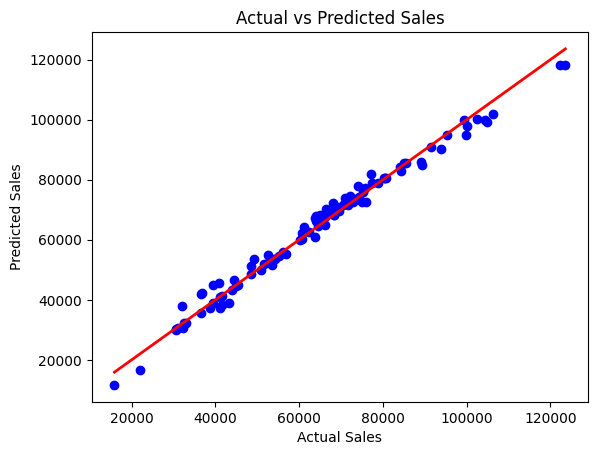

In [53]:
# Plot actual vs predicted values
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)  # Line of perfect fit
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

---

### **Impact of Including the Categorical Variable**

The inclusion of the **city** variable improved the model’s performance, as prices are affected by the geographical location. By **one-hot encoding** the city, we allowed the model to account for differences in prices patterns across regions.

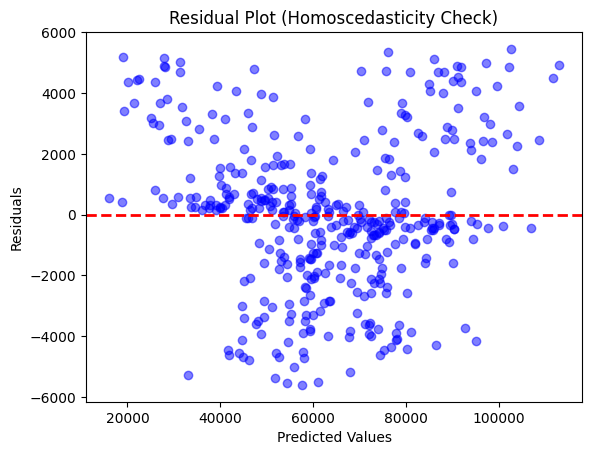

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Predict the target variable for the training set
y_train_pred = model.predict(X_train)

# Calculate residuals
residuals = y_train - y_train_pred

# Plot residuals vs. predicted values
plt.scatter(y_train_pred, residuals, color='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoscedasticity Check)")
plt.show()

The residual plot shows a **non-random pattern** for the residuals, suggesting that the current linear model may not adequately capture the underlying relationship in the data. 


### Suggestions for Further Investigation

1. **Check for Multicollinearity**: 
   - Use the Variance Inflation Factor (VIF) to identify any multicollinearity among predictors. High VIF values suggest multicollinearity issues.

2. **Standardize Features**: 
   - Standardizing features like `Square_Area` and `Floor_Level` may help improve the model’s stability and reduce residual patterns.

3. **Add Interaction Terms**: 
   - Introduce interaction terms, such as `Square_Area * City` or `Num_Rooms * City`, to capture any non-linear effects associated with specific features or cities.

4. **Try Regularized Regression**: 
   - Test models with Ridge or Lasso regularization to see if regularization can help mitigate residual patterns by reducing overfitting to specific features.

5. **Separate Residual Plots by City**:
   - Generate residual plots for each city individually to examine if residual patterns differ based on location, which could indicate city-specific effects not captured by the model.
  
6. **Try Non-Linear Models**:
   - Given the non-linear pattern in the residuals, experimenting with non-linear models could help capture complex relationships that a linear model might miss.
